Codes to Question 1_1

Implement the kalman filter for a multidimensional Linear Gaussian SSM (LG-SSM)

a. Consider a simplified case using scalars


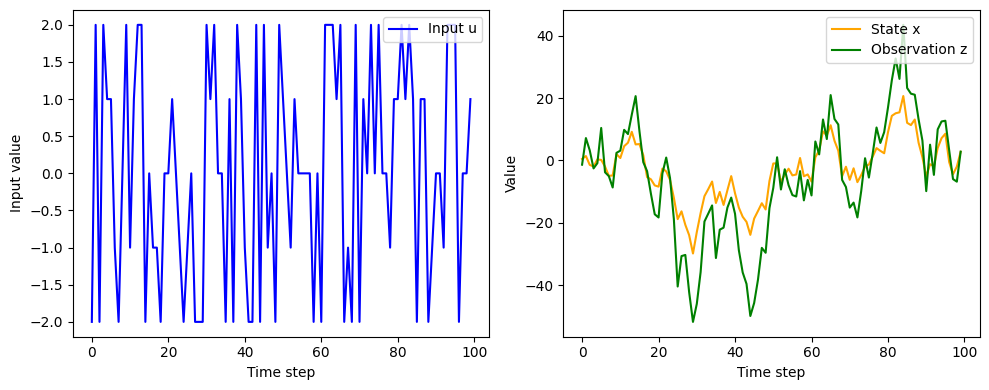

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# simulate some data
size = 100
np.random.seed(15) 

x0 = 0.5  # initial state
uk = np.random.choice(np.arange(-2, 3), size=size) # inputs
xk = np.zeros(uk.shape[0]) # hidden states
zk = np.zeros(uk.shape[0]) # observations

A = 0.9 
B = 2
C = 2
D = -1

Q = 2.9
R = 4

for i, u in enumerate(uk):
    if i == 0:
        xk[i] = x0
    else:
        xk[i] = A * xk[i - 1] + B * uk[i] + np.random.normal(0, Q)

    zk[i] = C * xk[i] + D * (uk[i]) + np.random.normal(0, R)

# plot inputs, hidden states, and observations
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(uk, label='Input u', color='blue')
plt.xlabel('Time step')
plt.ylabel('Input value')
plt.legend(loc='upper right')
plt.subplot(1, 2, 2)
plt.plot(xk, label='State x', color='orange')
plt.plot(zk, label='Observation z', color='green')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


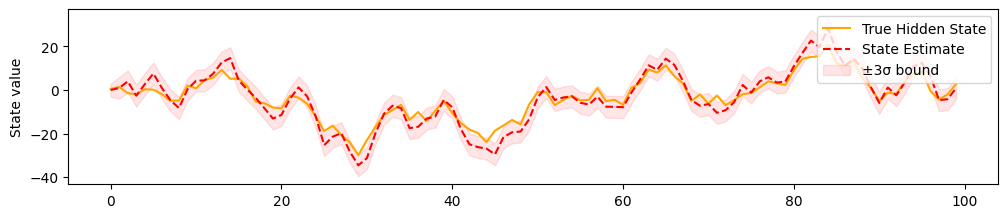

In [3]:
# implement the Kalman filter to estimate the hidden states from the observations and inputs
# initialize variables
params = {}
params["A"] = 0.4   # actual 0.9
params["B"] = 3     # actual 2
params["C"] = 1.0   # actual 2
params["D"] = -1.0  # actual -1
params["Q"] = 4.9   # actual 2.9
params["R"] = 6.0   # actual 4


size = len(zk)
time_idx = np.arange(size)

# initial guesses
xhat = 0.0  # state estimate at time 0
SigmaX = 1.0  # initial estimate error covariance
xhatstore = np.zeros(size)
boundstore = np.zeros(size)
xhatstore[0] = xhat
boundstore[0] = 3 * np.sqrt(SigmaX)

# execute Kalman filter
for t in range(1, size):
    # KF Step 1a: State estimate time update (prediction)
    xhat_pred = params["A"] * xhat + params["B"] * uk[t - 1]  # use prior value of "u"
    # KF Step 1b: Error covariance time update
    SigmaX_pred = params["A"] * SigmaX * params["A"] + params["Q"]
    # KF Step 1c: Estimate system output
    zhat = params["C"] * xhat_pred + params["D"] * uk[t]  # use present value of "u"

    # KF Step 2a: Compute Kalman gain
    L = SigmaX_pred * params["C"] / (params["C"] * SigmaX_pred * params["C"] + params["R"])
    # KF Step 2b: State estimate measurement update
    xhat = xhat_pred + L * (zk[t] - zhat)
    # KF Step 2c: Error covariance measurement update
    SigmaX = (1 - L * params["C"]) * SigmaX_pred
    SigmaX = max(SigmaX, 0.0)  # numerical guard against negative rounding errors

    # Store results for evaluation/plotting
    xhatstore[t] = xhat
    boundstore[t] = 3 * np.sqrt(SigmaX)


plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(time_idx, xk, label='True Hidden State', color='orange')
plt.plot(time_idx, xhatstore, label='State Estimate', color='red', linestyle='--')
plt.fill_between(time_idx, xhatstore - boundstore, xhatstore + boundstore, color='red', alpha=0.1, label='±3σ bound')
plt.ylabel('State value')
plt.legend(loc='upper right')


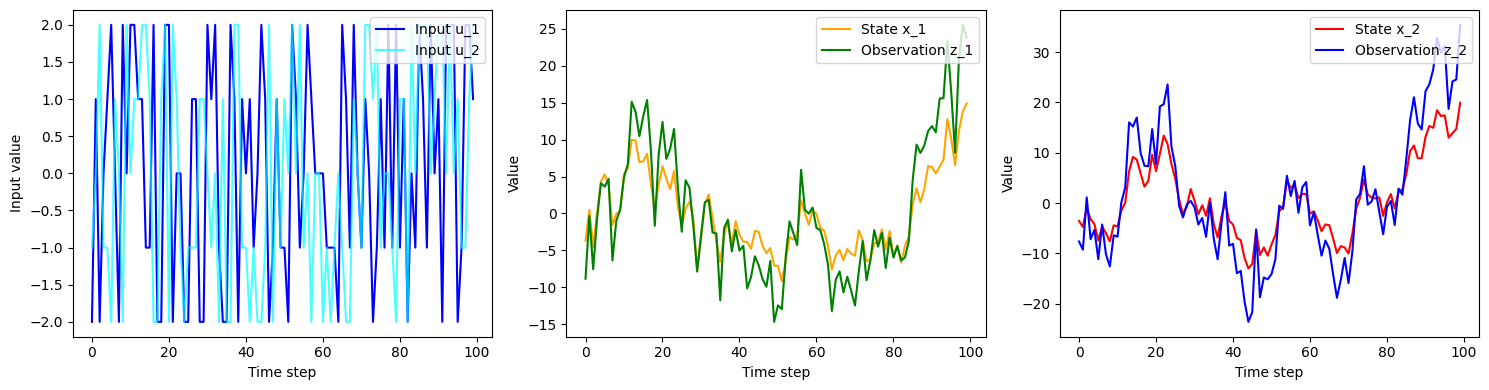

In [4]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(26)

#  Set sequence length
size = 100

# Dimensions
state_dim = 2
input_dim = 2
obs_dim = 2

# Initial state
x0 = np.array([0.5, -0.3])

uk = np.random.choice(np.arange(-2, 3), size=(size, input_dim)) # Random inputs
xk = np.zeros((size, state_dim)) # hidden states
zk = np.zeros((size, obs_dim)) # observations

# System matrices
A = np.array([[0.85, 0.1],
              [0.05, 0.9]])
B = np.array([[1.5, 0.2],
              [0.1, 1.8]])
C = np.array([[1.2, 0.4],
              [0.3, 1.5]])
D = np.array([[0.5, -0.3],
              [-0.2, 0.7]])

# Covariance matrices for process and measurement noise
Q = np.diag([2.0, 1.5])
R = np.diag([3.0, 2.5])

for i, u in enumerate(uk):
    process_noise = np.random.multivariate_normal(mean=np.zeros(state_dim), cov=Q)
    if i == 0:
        xk[i] = A @ x0 + B @ u + process_noise
    else:
        xk[i] = A @ xk[i - 1] + B @ u + process_noise

    measurement_noise = np.random.multivariate_normal(mean=np.zeros(obs_dim), cov=R)
    zk[i] = C @ xk[i] + D @ u + measurement_noise


plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(uk[:, 0], label='Input u_1', color='blue')
plt.plot(uk[:, 1], label='Input u_2', color='cyan', alpha=0.7)
plt.xlabel('Time step')
plt.ylabel('Input value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 2)
plt.plot(xk[:, 0], label='State x_1', color='orange')
plt.plot(zk[:, 0], label='Observation z_1', color='green')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 3)
plt.plot(xk[:, 1], label='State x_2', color='red')
plt.plot(zk[:, 1], label='Observation z_2', color='blue')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

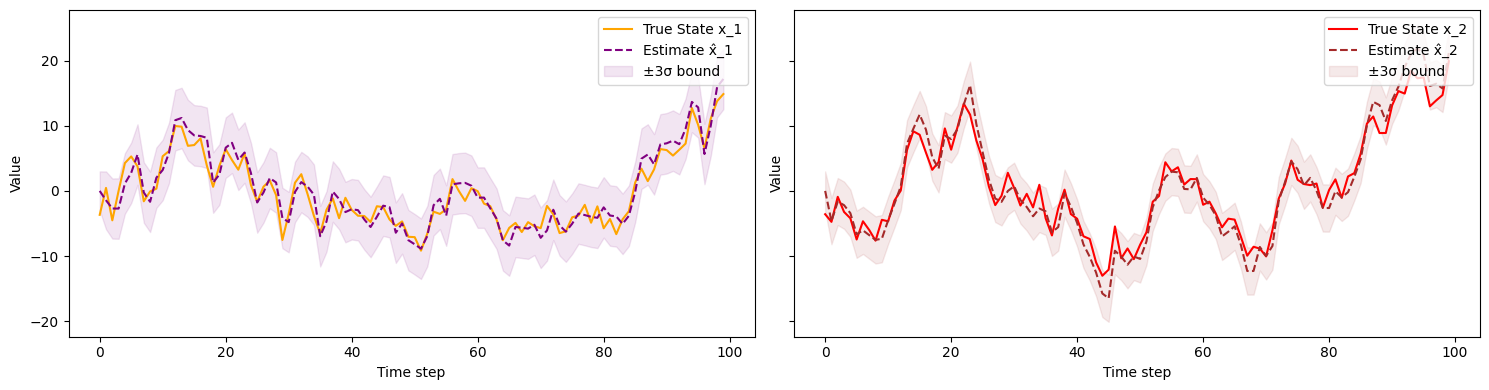

In [5]:
# implement the Kalman filter for the multidimensional LG-SSM
#  Set sequence length
size = 100
# Dimensions
state_dim = 2
input_dim = 2
obs_dim = 2

# initial model guess
params = {}
params["A"] = np.array([[0.75, 0.05],
                    [0.02, 0.8]])  
params["B"] = np.array([[1.2, 0.1],
                    [0.05, 1.4]])
params["C"] = np.array([[1.0, 0.3],
                    [0.2, 1.2]])
params["D"] = np.array([[0.4, -0.2],
                    [-0.1, 0.5]])
params["Q"] = np.diag([3.5, 2.5])
params["R"] = np.diag([4.5, 3.5])


time_idx = np.arange(size)
# initial guesses
xhat = np.zeros(state_dim)
SigmaX = np.eye(state_dim)
xhatstore = np.zeros((size, state_dim))
boundstore = np.zeros((size, state_dim))
xhatstore[0] = xhat
boundstore[0] = 3 * np.sqrt(np.diag(SigmaX))

# execute Kalman filter
for t in range(1, size):
    # KF Step 1a: State estimate time update (prediction)
    xhat_pred = params["A"] @ xhat + params["B"] @ uk[t - 1]
    # KF Step 1b: Error covariance time update
    SigmaX_pred = params["A"] @ SigmaX @ params["A"].T + params["Q"]
    # KF Step 1c: Estimate system output
    zhat = params["C"] @ xhat_pred + params["D"] @ uk[t]

    # KF Step 2a: Compute Kalman gain
    S = params["C"] @ SigmaX_pred @ params["C"].T + params["R"]
    L = SigmaX_pred @ params["C"].T @ np.linalg.inv(S)
    # KF Step 2b: State estimate measurement update
    xhat = xhat_pred + L @ (zk[t] - zhat)
    # KF Step 2c: Error covariance measurement update
    SigmaX = (np.eye(state_dim) - L @ params["C"]) @ SigmaX_pred

    SigmaX = (SigmaX + SigmaX.T) / 2.0
    SigmaX = np.maximum(SigmaX, 0.0)
    xhatstore[t] = xhat
    boundstore[t] = 3 * np.sqrt(np.clip(np.diag(SigmaX), a_min=0.0, a_max=None))

fig, axs = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
axs[0].plot(time_idx, xk[:, 0], label='True State x_1', color='orange')
axs[0].plot(time_idx, xhatstore[:, 0], label='Estimate x̂_1', color='purple', linestyle='--')
axs[0].fill_between(time_idx,
                    xhatstore[:, 0] - boundstore[:, 0],
                    xhatstore[:, 0] + boundstore[:, 0],
                    color='purple', alpha=0.1, label='±3σ bound')
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Value')
axs[0].legend(loc='upper right')

axs[1].plot(time_idx, xk[:, 1], label='True State x_2', color='red')
axs[1].plot(time_idx, xhatstore[:, 1], label='Estimate x̂_2', color='brown', linestyle='--')
axs[1].fill_between(time_idx,
                    xhatstore[:, 1] - boundstore[:, 1],
                    xhatstore[:, 1] + boundstore[:, 1],
                    color='brown', alpha=0.1, label='±3σ bound')
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Value')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

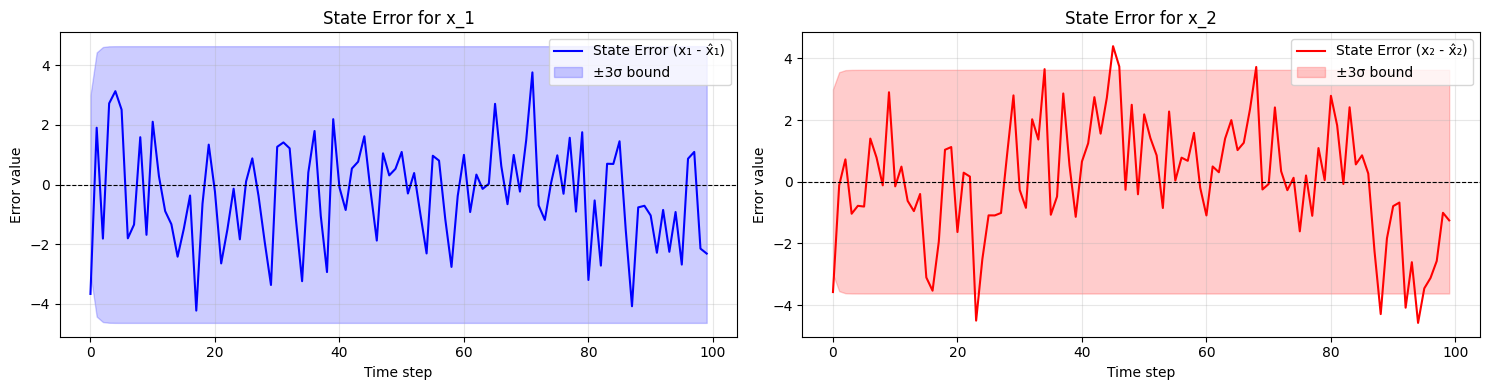

Percentage of x_1 errors within ±3σ bounds: 99.0%
Percentage of x_2 errors within ±3σ bounds: 91.0%


In [6]:
# State error with bounds
xerrKF = xk - xhatstore

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time_idx, xerrKF[:, 0], label='State Error (x₁ - x̂₁)', color='blue')
axs[0].fill_between(time_idx,
                    -boundstore[:, 0],
                    boundstore[:, 0],
                    color='blue', alpha=0.2, label='±3σ bound')
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Error value')
axs[0].set_title('State Error for x_1')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(time_idx, xerrKF[:, 1], label='State Error (x₂ - x̂₂)', color='red')
axs[1].fill_between(time_idx,
                    -boundstore[:, 1],
                    boundstore[:, 1],
                    color='red', alpha=0.2, label='±3σ bound')
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Error value')
axs[1].set_title('State Error for x_2')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage of errors within bounds
within_bounds_x1 = np.sum(np.abs(xerrKF[:, 0]) <= boundstore[:, 0]) / size * 100
within_bounds_x2 = np.sum(np.abs(xerrKF[:, 1]) <= boundstore[:, 1]) / size * 100
print(f"Percentage of x_1 errors within ±3σ bounds: {within_bounds_x1:.1f}%")
print(f"Percentage of x_2 errors within ±3σ bounds: {within_bounds_x2:.1f}%")